# `ferrodata` Walk-through

This notebook is a practical guide for:
- testing the new `ferrodata` package,
- reviewing parsed data structures,
- exporting human-readable CSV files,
- plotting `PUND`, `DHM`, and `Fatigue` data.

It uses the example files in `new ferro/`.

## 0) Import and Setup

If you open this notebook from the project root, the local package import should work directly.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from ferrodata import (
    read_dat,
    get_waveform_tables,
    get_fatigue_result_table,
    export_all_tables_csv,
    plot_pund,
    plot_dhm,
    plot_fatigue,
)

plt.rcParams.update({"figure.dpi": 110})

## 1) Point to Example Files

Edit these paths if your files are in another location.

In [2]:
base_dir = Path("examples")
example_files = {
    "pund": base_dir / "[example data]WMO 1-2-2 10IDE D1 PUND.dat",
    "dhm": base_dir / "[example data]WMO 1-2-2 10IDE D1 DHM.dat",
    "fatigue": base_dir / "[example data]WMO 1-2-2 50IDE D2 Fatigue.dat",
}

for name, path in example_files.items():
    print(f"{name:8s} -> {path} | exists={path.exists()}")

pund     -> new ferro/[example data]WMO 1-2-2 10IDE D1 PUND.dat | exists=True
dhm      -> new ferro/[example data]WMO 1-2-2 10IDE D1 DHM.dat | exists=True
fatigue  -> new ferro/[example data]WMO 1-2-2 50IDE D2 Fatigue.dat | exists=True


## 2) Parse Files

`read_dat(...)` returns a `MeasurementFile` object with:
- `measurement_type`
- `global_metadata`
- `tables`

In [4]:
parsed = {name: read_dat(path) for name, path in example_files.items()}

for name, obj in parsed.items():
    print(f" [{name}] type={obj.measurement_type.value}")
    print(f"  global metadata keys: {len(obj.global_metadata)}")
    print(f"  number of tables:      {len(obj.tables)}")

 [pund] type=pund
  global metadata keys: 7
  number of tables:      11
 [dhm] type=dhm
  global metadata keys: 7
  number of tables:      7
 [fatigue] type=fatigue
  global metadata keys: 45
  number of tables:      42


## 3) Inspect Table Structure

Use this helper to quickly inspect one table.

In [5]:
def inspect_table(table, n_rows=3):
    print(f"Table name: {table.name}")
    print(f"Columns: {len(table.headers)} | Rows: {table.data.shape[0]}")
    print("First 8 metadata items:")
    for i, (k, v) in enumerate(table.metadata.items()):
        if i >= 8:
            break
        print(f"  - {k}: {v}")

    if table.headers:
        print("\nHeaders (first 8):")
        print(table.headers[:8])

    if table.data.size:
        print("\nFirst rows:")
        print(table.data[:n_rows])


inspect_table(parsed["pund"].tables[0])

Table name: Table 1
Columns: 28 | Rows: 10
First 8 metadata items:

Headers (first 8):
['Table No [#]', 'Px [uC/cm2]', 'Pr+ [uC/cm2]', 'Pr- [uC/cm2]', 'Prrel+ [uC/cm2]', 'Prrel- [uC/cm2]', 'Psw [uC/cm2]', 'Pnsw [uC/cm2]']

First rows:
[[ 1.00000e+00 -4.04306e+01  2.53980e+02 -1.57532e+02 -1.25788e+01
  -1.28963e+01  3.22058e+02  3.21741e+02  3.17500e-01  0.00000e+00
   4.09950e+05  0.00000e+00  9.98579e+00 -9.99303e+00  3.09162e+02
  -3.09162e+02  6.62966e-05 -5.80704e-05  1.00000e-04  5.00000e-05
   1.00000e+01  5.00000e+03  1.00000e+01  1.00000e+00  9.00000e+01
   1.00000e+00  5.00000e+00  6.00000e+00]
 [ 2.00000e+00 -3.25295e+02  8.46732e+02 -6.58695e+02 -2.93841e+02
  -2.95149e+02  1.12961e+03  1.12830e+03  1.30800e+00  0.00000e+00
   2.31813e+05  1.00000e+00  1.49988e+01 -1.49872e+01  8.34459e+02
  -8.34459e+02  1.10811e-04 -9.64658e-05  1.00000e-04  5.00000e-05
   1.50000e+01  5.00000e+03  1.50000e+01  1.00000e+00  9.00000e+01
   1.00000e+00  5.00000e+00  6.00000e+00]
 [ 3.00000e

## 4) Export Tables to CSV

This writes each parsed table to one CSV file.

In [6]:
export_root = Path("ferrodata_exports")
export_root.mkdir(exist_ok=True)

for name, obj in parsed.items():
    out_dir = export_root / name
    csv_paths = export_all_tables_csv(obj, out_dir, include_metadata=True)
    print(f"{name:8s}: exported {len(csv_paths)} files -> {out_dir}")
    if csv_paths:
        print(f"  first file: {csv_paths[0].name}")

pund    : exported 11 files -> ferrodata_exports/pund
  first file: example_data_WMO_1-2-2_10IDE_D1_PUND_01_Table_1.csv
dhm     : exported 7 files -> ferrodata_exports/dhm
  first file: example_data_WMO_1-2-2_10IDE_D1_DHM_01_Table_1.csv
fatigue : exported 42 files -> ferrodata_exports/fatigue
  first file: example_data_WMO_1-2-2_50IDE_D2_Fatigue_01_Result_Table_1.csv


## 5) Plot PUND

Pick one waveform table and plot raw current, switched current density, and PU/ND polarization.

PUND waveform tables: 10


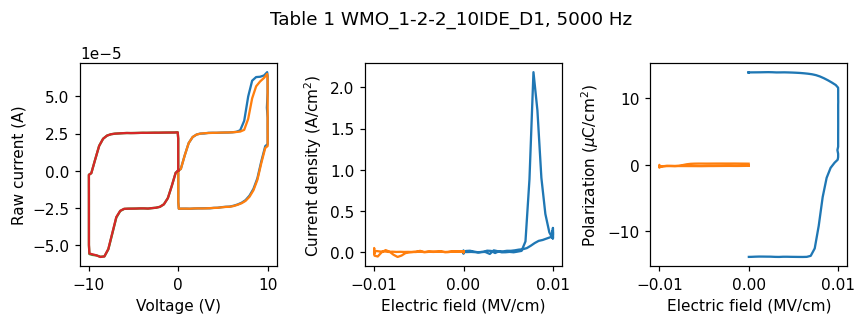

In [7]:
pund_wave_tables = get_waveform_tables(parsed["pund"])
print("PUND waveform tables:", len(pund_wave_tables))

fig, axes = plot_pund(pund_wave_tables[0], field_unit="MV/cm")
plt.show()

## 6) Plot DHM

Plot voltage, current, and polarization views from one DHM waveform table.

DHM waveform tables: 6


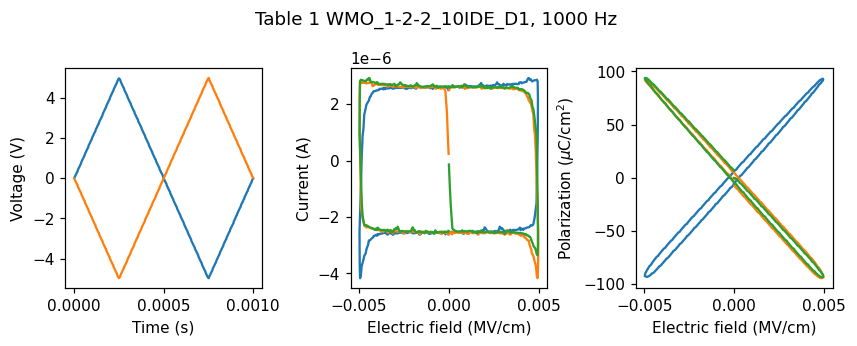

In [8]:
dhm_wave_tables = get_waveform_tables(parsed["dhm"])
print("DHM waveform tables:", len(dhm_wave_tables))

fig, axes = plot_dhm(dhm_wave_tables[0], field_unit="MV/cm")
plt.show()

## 7) Plot Fatigue Summary

Use `get_fatigue_result_table(...)` to fetch the summary table (cycles vs polarization metrics).

Fatigue result table: Result Table 1


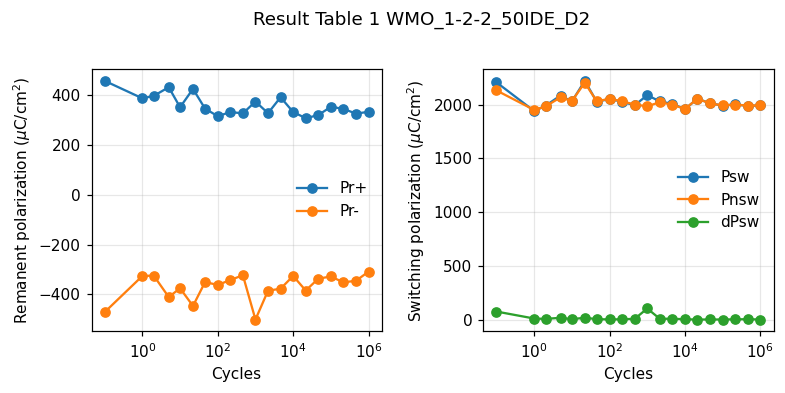

In [9]:
fatigue_result = get_fatigue_result_table(parsed["fatigue"])
print("Fatigue result table:", fatigue_result.name)

fig, axes = plot_fatigue(fatigue_result)
plt.show()

## 8) Minimal Reusable Workflow

This helper chooses a default plot based on measurement type.

In [10]:
def quick_plot(dat_path):
    m = read_dat(dat_path)
    print(f"type={m.measurement_type.value} | tables={len(m.tables)}")

    if m.measurement_type.value == "fatigue":
        table = get_fatigue_result_table(m)
        fig, _ = plot_fatigue(table)
    else:
        wave = get_waveform_tables(m)[0]
        if m.measurement_type.value == "pund":
            fig, _ = plot_pund(wave)
        else:
            fig, _ = plot_dhm(wave)

    return m, fig


# Example:
# m, fig = quick_plot(example_files["pund"])
# plt.show()

## Notes

- This walk-through intentionally uses the raw metadata in the file.
- For batch processing, loop over file paths and reuse the same API calls shown above.